Exercise

Download employee retention dataset from here: https://www.kaggle.com/giripujar/hr-analytics.

Now do some exploratory data analysis to figure out which variables have direct and clear impact on employee retention (i.e. whether they leave the company or continue to work)

Plot bar charts showing impact of employee salaries on retention

Plot bar charts showing corelation between department and employee retention

Now build logistic regression model using variables that were narrowed down in step 1

Measure the accuracy of the model

In [2]:
%matplotlib inline
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression, LogisticRegression, LogisticRegressionCV
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split

In [3]:
df = pd.read_csv('HR_comma_sep.csv')

In [12]:
df.head()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,Department,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.72,0.87,5,223,5,0,1,0,sales,low
4,0.37,0.52,2,159,3,0,1,0,sales,low


In [13]:
df = df.rename(columns={'average_montly_hours': 'average_monthly_hours', 'Work_accident': 'work_accident',
                        'promotion_last_5years': 'promotion_last_5_years', 'Department': 'department'})

In [14]:
df.head()

,satisfaction_level,last_evaluation,number_project,average_monthly_hours,time_spend_company,work_accident,left,promotion_last_5_years,department,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.72,0.87,5,223,5,0,1,0,sales,low
4,0.37,0.52,2,159,3,0,1,0,sales,low


In [6]:
#df.isna().sum()

In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14999 entries, 0 to 14998
Data columns (total 10 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   satisfaction_level      14999 non-null  float64
 1   last_evaluation         14999 non-null  float64
 2   number_project          14999 non-null  int64  
 3   average_monthly_hours   14999 non-null  int64  
 4   time_spend_company      14999 non-null  int64  
 5   work_accident           14999 non-null  int64  
 6   left                    14999 non-null  int64  
 7   promotion_last_5_years  14999 non-null  int64  
 8   department              14999 non-null  object 
 9   salary                  14999 non-null  object 
dtypes: float64(2), int64(6), object(2)
memory usage: 1.1+ MB


In [23]:
#df['promotion_last_5_years'].value_counts()

In [9]:
df['Department'] = df['Department'].str.replace('product_mng', 'product_manager')

In [10]:
df['Department'].value_counts()

Department
sales              4140
technical          2720
support            2229
IT                 1227
product_manager     902
marketing           858
RandD               787
accounting          767
hr                  739
management          630
Name: count, dtype: int64

In [82]:
#df1 = df.copy()

In [15]:
df.head()

,satisfaction_level,last_evaluation,number_project,average_monthly_hours,time_spend_company,work_accident,left,promotion_last_5_years,department,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.72,0.87,5,223,5,0,1,0,sales,low
4,0.37,0.52,2,159,3,0,1,0,sales,low


In [34]:
df.shape

(14999, 10)

In [30]:
left = df[df.left == 1]

In [31]:
left.shape

(3571, 10)

In [32]:
stayed = df[df.left == 0]

In [33]:
stayed.shape

(11428, 10)

In [36]:
df.groupby('left').mean(numeric_only=True)

,satisfaction_level,last_evaluation,number_project,average_monthly_hours,time_spend_company,work_accident,promotion_last_5_years
left,,,,,,,
0,0.666810,0.715473,3.786664,199.060203,3.380032,0.175009,0.026251
1,0.440098,0.718113,3.855503,207.419210,3.876505,0.047326,0.005321


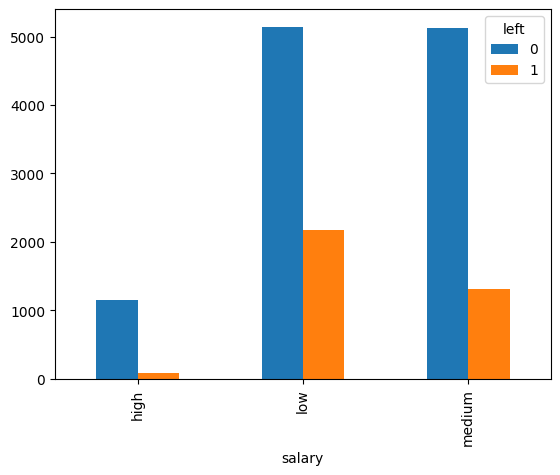

In [39]:
pd.crosstab(df.salary, df.left).plot(kind='bar')
plt.show()

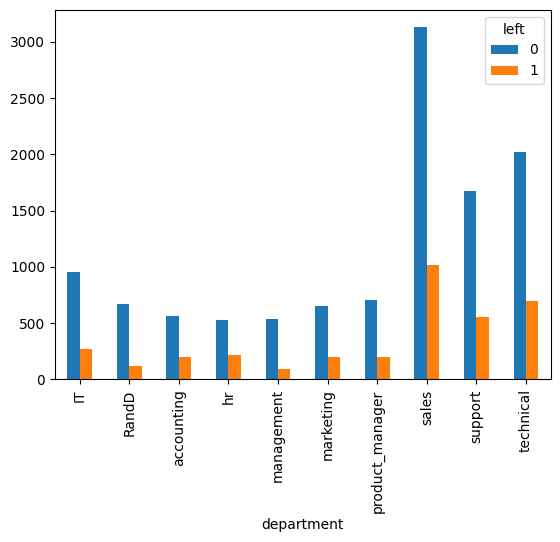

In [40]:
pd.crosstab(df.department, df.left).plot(kind='bar')
plt.show()

In [45]:
#pd.crosstab(df.time_spend_company, df.left).plot(kind='bar')
#plt.show()

<Axes: >

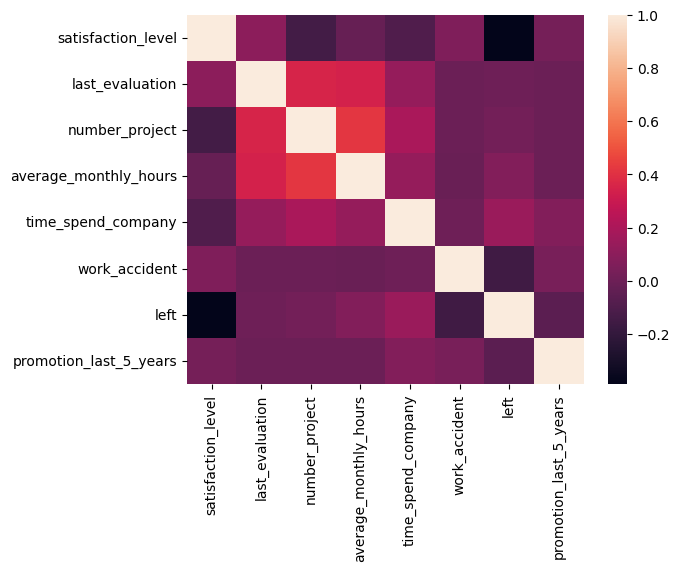

In [16]:
sns.heatmap(df.corr(numeric_only=True))

In [43]:
df.head(2)

,satisfaction_level,last_evaluation,number_project,average_monthly_hours,time_spend_company,work_accident,left,promotion_last_5_years,department,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium


In [95]:
new_df = df[['satisfaction_level', 'average_monthly_hours', 'promotion_last_5_years', 'salary']]
new_df.head()

,satisfaction_level,average_monthly_hours,promotion_last_5_years,salary
0,0.38,157,0,low
1,0.80,262,0,medium
2,0.11,272,0,medium
3,0.72,223,0,low
4,0.37,159,0,low


In [54]:
#da = pd.get_dummies(new_df, dtype='int')
#da

In [96]:
new_df = pd.get_dummies(new_df, dtype='int')

In [97]:
new_df.head()

,satisfaction_level,average_monthly_hours,promotion_last_5_years,salary_high,salary_low,salary_medium
0,0.38,157,0,0,1,0
1,0.80,262,0,0,0,1
2,0.11,272,0,0,0,1
3,0.72,223,0,0,1,0
4,0.37,159,0,0,1,0


In [98]:
X = new_df
y = df.left

In [99]:
X.shape

(14999, 6)

In [100]:
y.shape

(14999,)

In [105]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size= 0.3)
log_reg = LogisticRegression() # max_iter=1000)
log_reg.fit(X_train, y_train)

LogisticRegression()

In [106]:
X_test

,satisfaction_level,average_monthly_hours,promotion_last_5_years,salary_high,salary_low,salary_medium
10818,0.63,151,0,0,0,1
795,0.43,150,0,0,1,0
6666,0.88,185,0,0,1,0
6988,0.61,256,0,0,0,1
2094,0.48,151,0,0,0,1
...,...,...,...,...,...,...
10631,0.60,165,0,0,0,1
8515,0.84,163,0,0,1,0
11076,0.59,197,0,0,0,1
13956,0.27,108,0,0,0,1


In [107]:
pred = log_reg.predict(X_test)
print(pred)

[0 0 0 ... 0 0 0]


In [108]:
log_reg.score(X_test,y_test)

0.77